In [2]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from gprofiler import GProfiler


In [3]:
GO_BP = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-BP.csv', index_col=0)
GO_CC = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-CC.csv', index_col=0)
GO_MF = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-MF.csv', index_col=0)
HPO   = pd.read_csv('data/gene_hpo_matrix_binary_withAncestors_namespace_Phenotypic abnormality.csv', index_col=0)

In [4]:
view1 = pd.read_csv('clusters/GO_BP-clusters.csv')
view2 = pd.read_csv('clusters/GO_MF-clusters.csv')
view3 = pd.read_csv('clusters/GO_CC-clusters.csv')
view4 = pd.read_csv('clusters/HPO-clusters.csv')
mofa = pd.read_csv('clusters/mofa-clusters.csv')

clusterings = {
    'GO_BP': view1,
    'GO_MF': view2,
    'GO_CC': view3,
    'HPO': view4,
    'MOFA': mofa
}

In [5]:
def build_coassignment_matrix(clusterings, views_to_include=None, ks_to_include=None):
    """
    Build the co-assignment matrix from multiple clusterings.

    Parameters
    ----------
    clusterings : dict
        {view_name: DataFrame with shape (n_samples, n_k)}
    views_to_include : list of str, optional
        Which views to include (default all)
    ks_to_include : list of int, optional
        Which k values to include (default all ks in clusterings)

    Returns
    -------
    coassign : np.ndarray, shape (n_samples, n_samples)
        Fraction of clusterings in which each pair of samples is in the same cluster
    """
    if views_to_include is None:
        views_to_include = list(clusterings.keys())

    # Determine ks
    if ks_to_include is None:
        # use all columns in first view
        ks_to_include = [int(c) for c in clusterings[views_to_include[0]].columns]

    n_samples = clusterings[views_to_include[0]].shape[0]
    coassign = np.zeros((n_samples, n_samples), dtype=float)
    n_total = 0

    for view in views_to_include:
        df = clusterings[view]
        for k in ks_to_include:
            labels = df[str(k)].values.ravel()
            # build co-assignment for this clustering
            for i in range(n_samples):
                for j in range(i, n_samples):
                    if labels[i] == labels[j]:
                        coassign[i, j] += 1
                        if i != j:
                            coassign[j, i] += 1
            n_total += 1

    coassign /= n_total
    return coassign


def consensus_clustering(coassign_matrix, n_clusters=10, method='average'):
    """
    Compute consensus clusters using hierarchical clustering.

    Parameters
    ----------
    coassign_matrix : np.ndarray
        n_samples x n_samples co-assignment matrix
    n_clusters : int
        Number of consensus clusters
    method : str
        Linkage method for hierarchical clustering (default 'average')

    Returns
    -------
    labels : np.ndarray, shape (n_samples,)
        Consensus cluster labels (1..n_clusters)
    """
    # Convert similarity to distance
    distance = 1.0 - coassign_matrix

    # Condensed distance matrix for linkage
    from scipy.spatial.distance import squareform
    dist_condensed = squareform(distance, checks=False)

    Z = linkage(dist_condensed, method=method)
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    return labels

## Consensus CDF method for choosing optimal k

Best number of clusters (ΔCDF):
  MOFA-only: 10
  GO+HPO   : 3


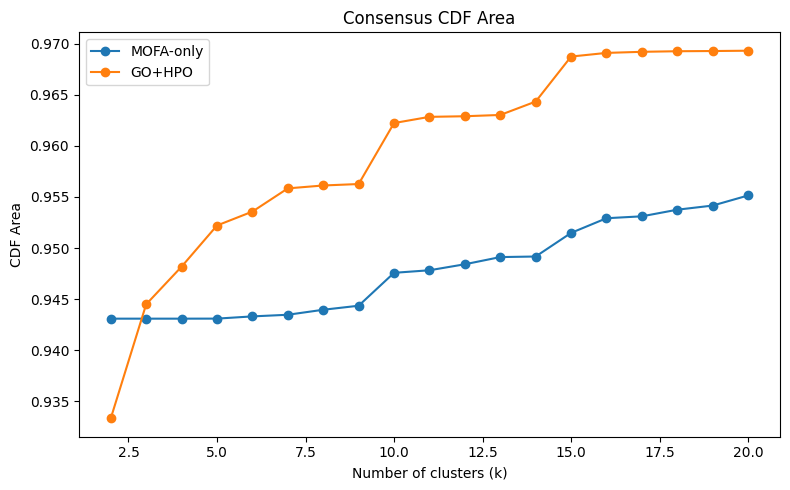

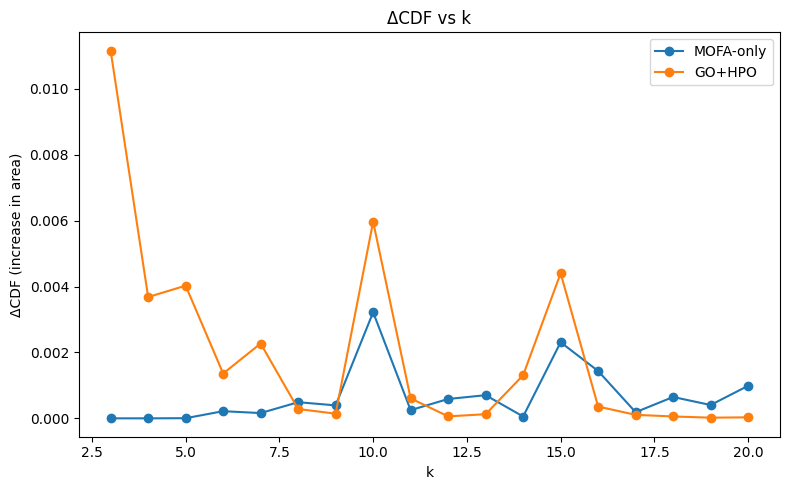

In [8]:
def consensus_cdf(consensus_matrix, bins=100):
    """
    Compute CDF of consensus values (upper triangle excluding diagonal).
    """
    vals = consensus_matrix[np.triu_indices_from(consensus_matrix, k=1)]
    hist, bin_edges = np.histogram(vals, bins=bins, range=(0,1), density=True)
    cdf = np.cumsum(hist) / np.sum(hist)
    return cdf, bin_edges[1:]  # cdf values and x-axis


def compute_cdf_scores(coassign_matrix, k_range):
    """
    For each k, compute:
      - consensus labels
      - within-cluster consensus scores
      - CDF area
    Returns dict of results.
    """
    results = {}
    distance = 1 - coassign_matrix

    for k in k_range:
        labels = consensus_clustering(coassign_matrix, n_clusters=k)

        # Build consensus matrix for clusters only
        n = len(labels)
        consensus_within = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j]:
                    consensus_within[i, j] = coassign_matrix[i, j]

        # CDF of within-cluster agreement
        cdf, bins = consensus_cdf(consensus_within)
        auc = np.trapz(cdf, bins)   # area under CDF curve

        results[k] = {
            "labels": labels,
            "cdf": cdf,
            "bins": bins,
            "auc": auc,
        }

    return results


def find_optimal_k(cdf_results):
    """
    Choose optimal k using ΔCDF method.
    """
    ks = sorted(cdf_results.keys())
    aucs = [cdf_results[k]['auc'] for k in ks]

    deltas = np.diff(aucs)
    best_idx = np.argmax(deltas)  # biggest jump
    best_k = ks[best_idx + 1]     # delta is between k and k+1

    return best_k, ks, aucs, deltas

# Define views
mofa_view = ['MOFA']
gohpo_views = ['GO_BP', 'GO_MF', 'GO_CC', 'HPO']

# Build co-assignment matrices for both configurations
coassign_mofa = build_coassignment_matrix(
    clusterings,
    views_to_include=mofa_view,
    ks_to_include=range(20, 51)  # pick stable ks
)

coassign_gohpo = build_coassignment_matrix(
    clusterings,
    views_to_include=gohpo_views,
    ks_to_include=range(20, 51)
)

# Evaluate CDFs and choose best k for each
k_range = range(2, 21)

cdf_results_mofa = compute_cdf_scores(coassign_mofa, k_range)
best_k_mofa, ks_mofa, aucs_mofa, deltas_mofa = find_optimal_k(cdf_results_mofa)

cdf_results_gohpo = compute_cdf_scores(coassign_gohpo, k_range)
best_k_gohpo, ks_gohpo, aucs_gohpo, deltas_gohpo = find_optimal_k(cdf_results_gohpo)

print("Best number of clusters (ΔCDF):")
print(f"  MOFA-only: {best_k_mofa}")
print(f"  GO+HPO   : {best_k_gohpo}")

# Plot AUC curves together
plt.figure(figsize=(8,5))
plt.plot(ks_mofa, aucs_mofa, "-o", label="MOFA-only")
plt.plot(ks_gohpo, aucs_gohpo, "-o", label="GO+HPO")
plt.xlabel("Number of clusters (k)")
plt.ylabel("CDF Area")
plt.title("Consensus CDF Area")
plt.legend()
plt.tight_layout()
plt.show()

# Plot ΔCDF together
plt.figure(figsize=(8,5))
plt.plot(ks_mofa[1:], deltas_mofa, "-o", label="MOFA-only")
plt.plot(ks_gohpo[1:], deltas_gohpo, "-o", label="GO+HPO")
plt.xlabel("k")
plt.ylabel("ΔCDF (increase in area)")
plt.title("ΔCDF vs k")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Step 2: compute consensus clusters for both configurations
n_consensus_clusters_mofa = 10
labels_mofa = consensus_clustering(coassign_mofa, n_clusters=n_consensus_clusters_mofa)

n_consensus_clusters_gohpo = 10
labels_gohpo = consensus_clustering(coassign_gohpo, n_clusters=n_consensus_clusters_gohpo)

# Step 3: view results
print("Consensus cluster counts (MOFA-only):")
print(pd.Series(labels_mofa).value_counts().sort_index())
print("\nConsensus cluster counts (GO+HPO):")
print(pd.Series(labels_gohpo).value_counts().sort_index())

Consensus cluster counts (MOFA-only):
1      579
2      202
3      112
4      241
5      187
6     1984
7     1783
8       18
9       48
10      29
Name: count, dtype: int64

Consensus cluster counts (GO+HPO):
1       70
2     1082
3      377
4      157
5      239
6      129
7      215
8      624
9     2289
10       1
Name: count, dtype: int64


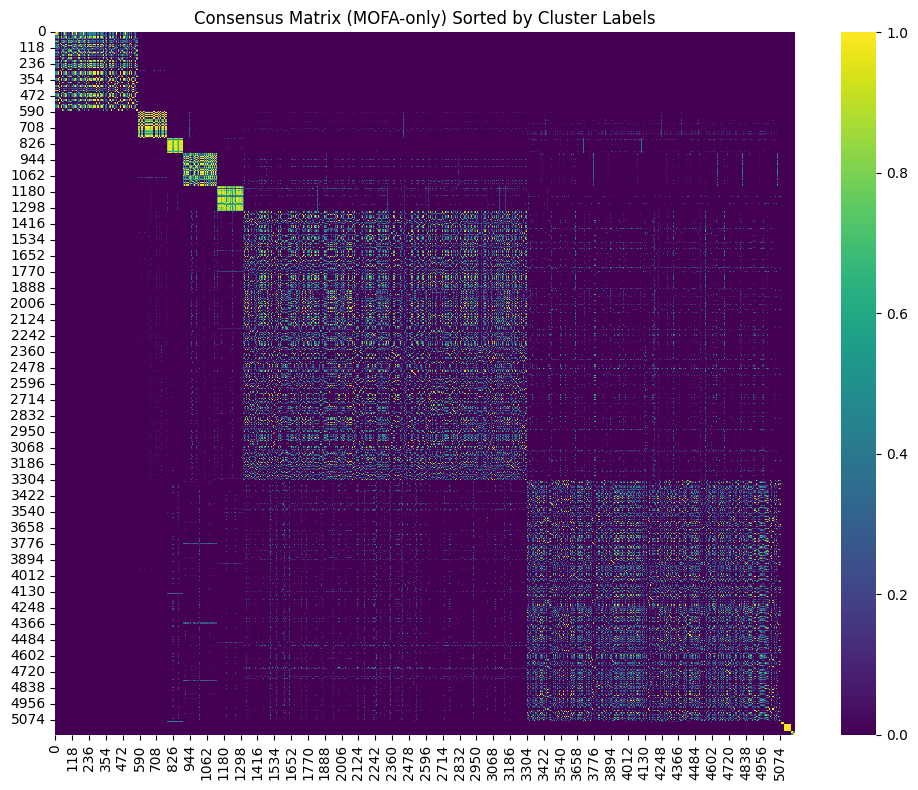

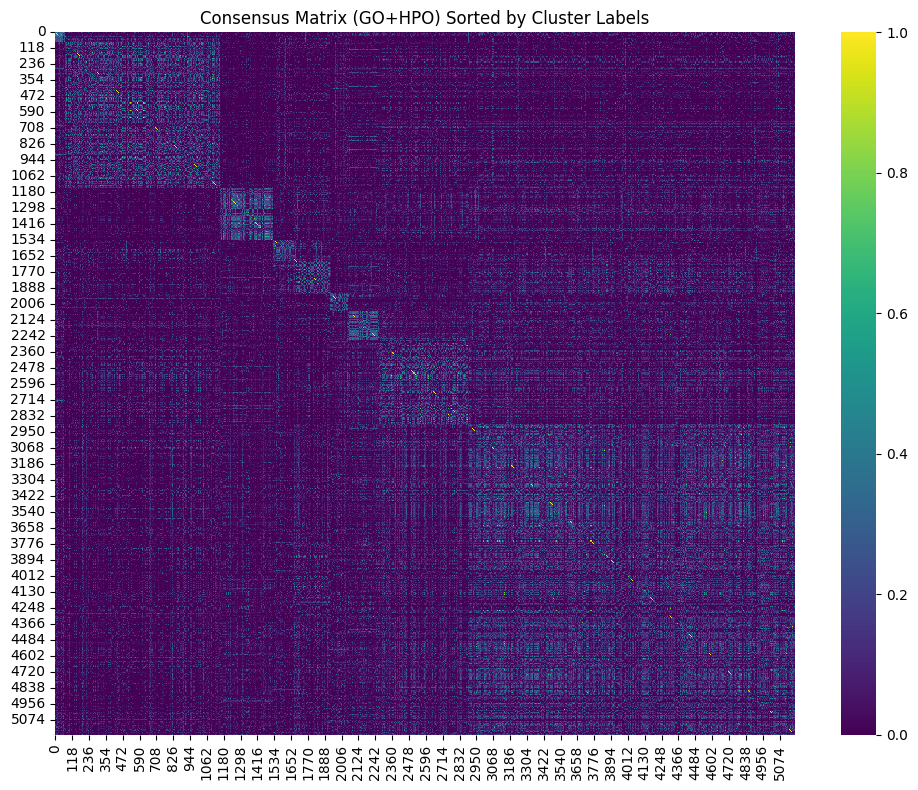

In [10]:
# Heatmaps of consensus matrices sorted by cluster labels for both configurations
# MOFA-only
order_mofa = np.argsort(labels_mofa)
plt.figure(figsize=(10, 8))
sns.heatmap(coassign_mofa[order_mofa][:, order_mofa], cmap="viridis")
plt.title("Consensus Matrix (MOFA-only) Sorted by Cluster Labels")
plt.tight_layout()
plt.show()

# GO+HPO
order_gohpo = np.argsort(labels_gohpo)
plt.figure(figsize=(10, 8))
sns.heatmap(coassign_gohpo[order_gohpo][:, order_gohpo], cmap="viridis")
plt.title("Consensus Matrix (GO+HPO) Sorted by Cluster Labels")
plt.tight_layout()
plt.show()

In [11]:
# Cluster cohesion strength per consensus cluster (mean within-cluster coassignments)
strength_mofa = {}
for k in labels_mofa:
    idx = np.where(labels_mofa == k)[0]
    sub = coassign_mofa[np.ix_(idx, idx)]
    vals = sub[np.triu_indices(len(idx), k=1)]
    strength_mofa[k] = vals.mean() if len(vals) > 0 else np.nan

strength_gohpo = {}
for k in labels_gohpo:
    idx = np.where(labels_gohpo == k)[0]
    sub = coassign_gohpo[np.ix_(idx, idx)]
    vals = sub[np.triu_indices(len(idx), k=1)]
    strength_gohpo[k] = vals.mean() if len(vals) > 0 else np.nan

print("Strength by cluster (MOFA-only):")
print({int(k): float(v) for k, v in strength_mofa.items()})
print("\nStrength by cluster (GO+HPO):")
print({int(k): float(v) for k, v in strength_gohpo.items()})


Strength by cluster (MOFA-only):
{6: 0.14849692403641146, 3: 0.8053670029476482, 7: 0.1268742318380779, 2: 0.49174440795066504, 10: 0.7163515016685204, 1: 0.2802716115499104, 4: 0.5366071030205685, 5: 0.755064262011682, 9: 1.0, 8: 1.0}

Strength by cluster (GO+HPO):
{9: 0.10620547143002014, 8: 0.13264958205380464, 3: 0.17667179754191328, 4: 0.15842763667398965, 7: 0.18982198820733223, 5: 0.14431885589976307, 2: 0.12124053011864504, 1: 0.3263774794630334, 6: 0.17238782351837958, 10: nan}


In [12]:
# Enrichment helper to run g:Profiler for a given set of consensus labels

def run_enrichment(consensus_labels):
    # Build gene universe (Entrez IDs) from GO_BP and map to consensus clusters

    # We assume the clustering rows are in the same order as GO_BP rows
    # (this is how the co-assignment was built across views)

    # 1) Gene list as Entrez IDs from GO_BP index
    genes = GO_BP.index.astype(str).tolist()

    # 2) Sanity checks: clustering tables must have same number of rows
    n_rows = len(genes)
    for view_name, df in clusterings.items():
        assert df.shape[0] == n_rows, f"Row mismatch: {view_name} has {df.shape[0]}, GO_BP has {n_rows}"

    assert len(consensus_labels) == n_rows, (
        f"Consensus labels length {len(consensus_labels)} != number of genes {n_rows}"
    )

    # 3) Map consensus cluster ID -> list of Entrez IDs
    clusters_genes = {}
    for cid in np.unique(consensus_labels):
        idx = np.where(consensus_labels == cid)[0]
        clusters_genes[int(cid)] = [genes[i] for i in idx]

    # 4) Define universe as all measured genes
    universe_genes = genes

    # Initialize g:Profiler client (returns pandas DataFrame)
    gp = GProfiler(return_dataframe=True)

    # Choose sources; tweak as needed
    sources = ["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG", "HP"]

    all_results = []
    for cid, gene_list in clusters_genes.items():
        # skip tiny clusters
        if len(gene_list) < 3:
            continue
        try:
            res = gp.profile(
                organism="hsapiens",                    # adjust if not human
                query=gene_list,                         # genes in the cluster
                background=universe_genes,               # custom background (all genes measured)
                sources=sources,
            )
        except Exception as e:
            print(f"Cluster {cid}: enrichment failed: {e}")
            res = None

        if res is not None and len(res) > 0:
            res["cluster_id"] = cid
            res["cluster_size"] = len(gene_list)
            # -log10(FDR) for plotting
            if "p_value" in res.columns:
                res["neglog10_p"] = -np.log10(res["p_value"].clip(lower=1e-300))
            all_results.append(res)
        else:
            print(f"Cluster {cid}: no significant terms (check gene IDs / organism).")

    if len(all_results) > 0:
        enr_df = pd.concat(all_results, ignore_index=True)
        # Sort within cluster by adjusted p-value
        if "p_value" in enr_df.columns:
            enr_df = enr_df.sort_values(["cluster_id", "p_value"], ascending=[True, True])
        return enr_df
    else:
        return None

# Run enrichment for both sets of consensus labels
enr_df_mofa = run_enrichment(labels_mofa)
enr_df_gohpo = run_enrichment(labels_gohpo)

# Quick summaries
for name, df in [("MOFA-only", enr_df_mofa), ("GO+HPO", enr_df_gohpo)]:
    if df is not None and len(df) > 0:
        print(f"Significant terms per cluster ({name}):")
        print(df.groupby("cluster_id").size())
    else:
        print(f"No enrichment results for {name}.")

Significant terms per cluster (MOFA-only):
cluster_id
1     1727
2      269
3      559
4      480
5      530
6      643
7     1173
8      585
9      263
10     331
dtype: int64
Significant terms per cluster (GO+HPO):
cluster_id
1      81
2    1468
3     752
4     489
5    1072
6     315
7     138
8     563
9     289
dtype: int64


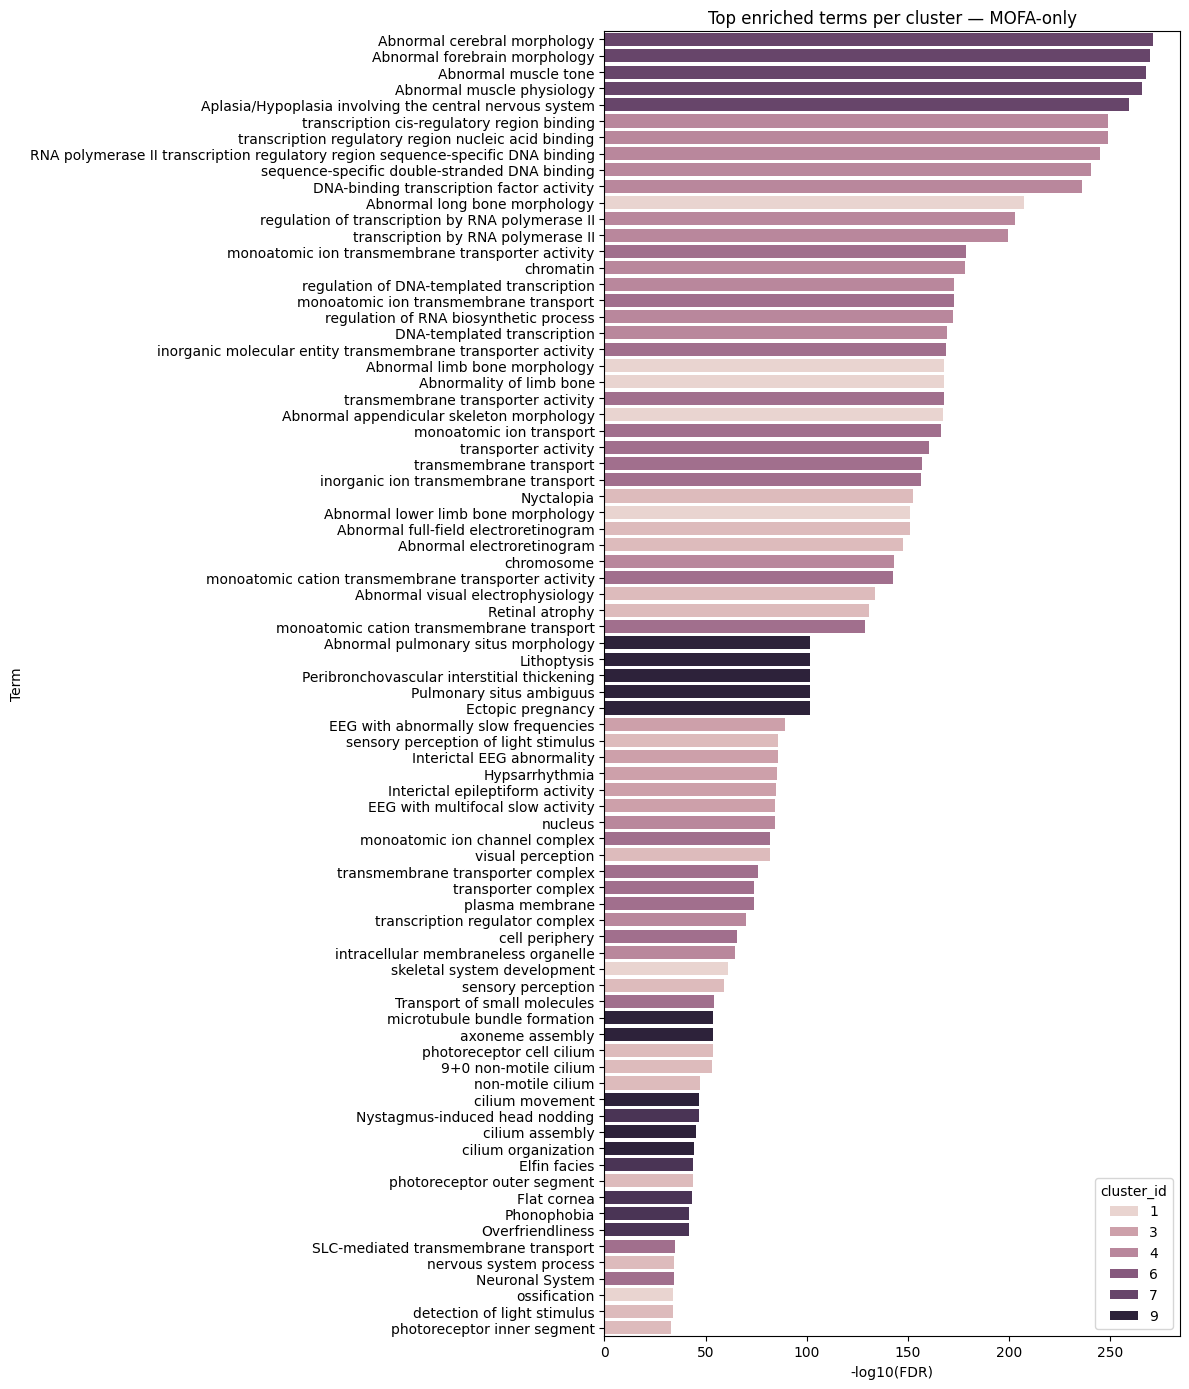

/var/folders/49/2vtyfv4n7cxb_hl_7_5wf97w0000gn/T/ipykernel_2638/2280693963.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: ", ".join(d.head(3)[term_col].tolist()))


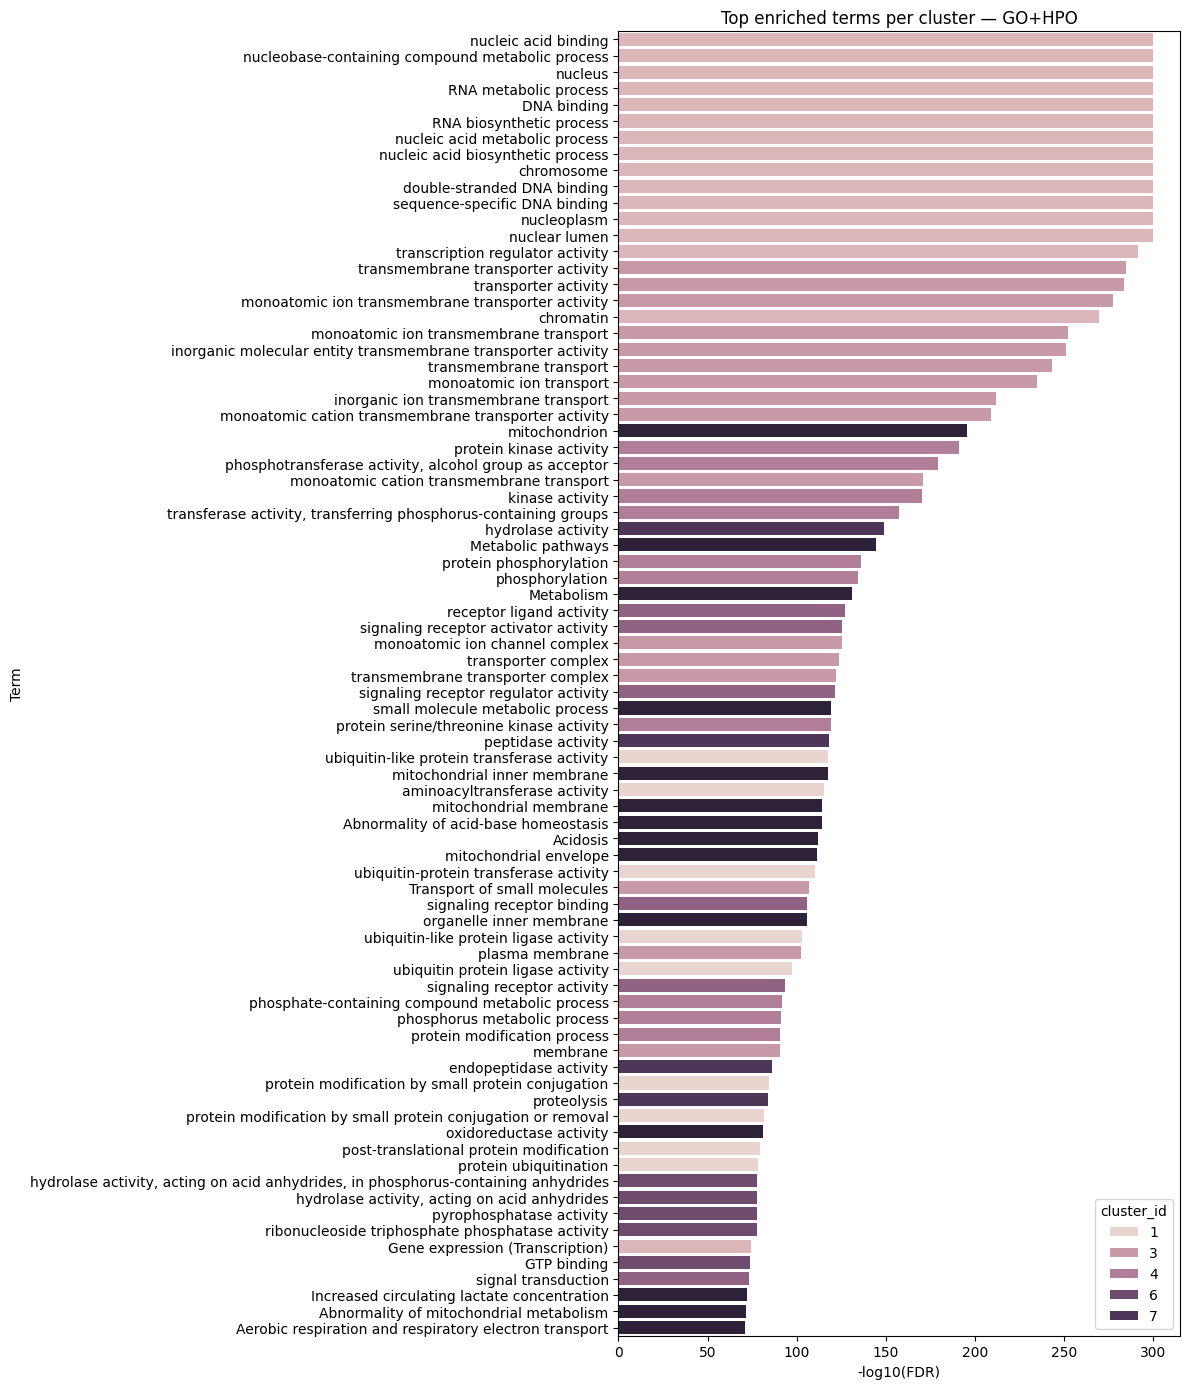

/var/folders/49/2vtyfv4n7cxb_hl_7_5wf97w0000gn/T/ipykernel_2638/2280693963.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: ", ".join(d.head(3)[term_col].tolist()))


In [13]:
def plot_enrichment_summary(enr_df, title_suffix):
    if enr_df is None or not isinstance(enr_df, pd.DataFrame) or len(enr_df) == 0:
        print(f"No enrichment results to plot for {title_suffix}.")
        return None

    # Pick the correct term column for display
    term_col = "term_name" if "term_name" in enr_df.columns else ("name" if "name" in enr_df.columns else None)
    if term_col is None:
        display(enr_df.head(10))
        return None

    # Ensure plotting score exists
    if "neglog10_p" not in enr_df.columns and "p_value" in enr_df.columns:
        enr_df["neglog10_p"] = -np.log10(enr_df["p_value"].clip(lower=1e-300))

    # Plot: top 5 terms per source per cluster (by FDR)
    if "p_value" in enr_df.columns:
        top_df = (enr_df
                  .sort_values("p_value")
                  .groupby(["cluster_id", "source"], as_index=False)
                  .head(5))
        max_terms = min(80, len(top_df))
        plot_df = top_df.head(max_terms)

        plt.figure(figsize=(12, max(4, int(len(plot_df) * 0.18))))
        sns.barplot(data=plot_df, x="neglog10_p", y=term_col, hue="cluster_id", dodge=False)
        plt.xlabel("-log10(FDR)")
        plt.ylabel("Term")
        plt.title(f"Top enriched terms per cluster — {title_suffix}")
        plt.tight_layout()
        plt.show()

        # Also save condensed top terms per cluster table
        top_table = (top_df
                     .groupby(["cluster_id", "source"])
                     .apply(lambda d: ", ".join(d.head(3)[term_col].tolist()))
                     .reset_index(name="top_terms"))
        return top_table
    else:
        print(f"No p_value column for {title_suffix}.")
        return None

# Plot for both consensus results
top_table_mofa = plot_enrichment_summary(enr_df_mofa, "MOFA-only")
top_table_gohpo = plot_enrichment_summary(enr_df_gohpo, "GO+HPO")

In [15]:
# Select top GO:BP terms per consensus cluster for a given enrichment table

def select_top_bp(enr_df, top_k=3):
    if enr_df is None or not isinstance(enr_df, pd.DataFrame) or len(enr_df) == 0:
        raise RuntimeError("enr_df is missing or empty. Run the enrichment for this consensus first.")

    # Accept common GO:BP source labels across versions
    bp_sources = {"GO:BP", "BP", "GOBP"}
    df_bp = enr_df[enr_df["source"].isin(bp_sources)].copy()
    if df_bp.empty:
        raise RuntimeError("No GO:BP terms found in enrichment results. Check sources or thresholds.")

    # Robust term ID / name columns across gprofiler-official versions
    id_col = "native" if "native" in df_bp.columns else ("term_id" if "term_id" in df_bp.columns else None)
    name_col = "term_name" if "term_name" in df_bp.columns else ("name" if "name" in df_bp.columns else None)
    if id_col is None:
        raise KeyError(f"No GO term ID column found in enrichment results. Columns: {list(df_bp.columns)}")
    if name_col is None:
        raise KeyError(f"No GO term name column found in enrichment results. Columns: {list(df_bp.columns)}")

    # Ensure plotting score exists
    if "neglog10_p" not in df_bp.columns and "p_value" in df_bp.columns:
        df_bp["neglog10_p"] = -np.log10(df_bp["p_value"].clip(lower=1e-300))

    # Take top-k terms per cluster by p-value, and keep the best cluster if a term appears in multiple clusters
    _top = (df_bp.sort_values(["cluster_id", "p_value"], ascending=[True, True])
                 .groupby("cluster_id", group_keys=False)
                 .head(top_k))
    # Deduplicate by term ID keeping the row with lowest p-value across clusters
    top_bp = _top.loc[_top.groupby(id_col)["p_value"].idxmin()].copy()

    # Dictionaries for plotting
    go_to_cluster = {row[id_col]: int(row["cluster_id"]) for _, row in top_bp.iterrows()}
    go_to_score   = {row[id_col]: float(row.get("neglog10_p", 1.0)) for _, row in top_bp.iterrows()}  # significance (-log10 FDR)
    go_to_name    = {row[id_col]: str(row[name_col]) for _, row in top_bp.iterrows()}
    # Term frequency in the query: use intersection_size when available
    go_to_freq    = {row[id_col]: int(row.get("intersection_size", 1)) for _, row in top_bp.iterrows()}

    return top_bp, go_to_cluster, go_to_score, go_to_name, go_to_freq

# Build selections for both consensus results
top_bp_mofa, go_to_cluster_mofa, go_to_score_mofa, go_to_name_mofa, go_to_freq_mofa = select_top_bp(enr_df_mofa, top_k=3)
print(f"Selected {len(top_bp_mofa)} GO:BP terms across {top_bp_mofa['cluster_id'].nunique()} clusters (top 3 per cluster) — MOFA-only.")

top_bp_gohpo, go_to_cluster_gohpo, go_to_score_gohpo, go_to_name_gohpo, go_to_freq_gohpo = select_top_bp(enr_df_gohpo, top_k=3)
print(f"Selected {len(top_bp_gohpo)} GO:BP terms across {top_bp_gohpo['cluster_id'].nunique()} clusters (top 3 per cluster) — GO+HPO.")

Selected 27 GO:BP terms across 9 clusters (top 3 per cluster) — MOFA-only.
Selected 27 GO:BP terms across 9 clusters (top 3 per cluster) — GO+HPO.


In [16]:
# Load GO DAG (go-basic.obo) via obonet
import os

try:
    import obonet
    import networkx as nx
except ImportError as e:
    raise ImportError("Missing packages. Install with: pip install obonet networkx")

obo_path = os.path.join("data", "go-basic.obo")
if os.path.exists(obo_path):
    G = obonet.read_obo(obo_path)
else:
    # Download from the official URL and cache in data/
    url = "https://purl.obolibrary.org/obo/go/go-basic.obo"
    os.makedirs("data", exist_ok=True)
    try:
        import urllib.request
        print("Downloading go-basic.obo ...")
        urllib.request.urlretrieve(url, obo_path)
        G = obonet.read_obo(obo_path)
        print(f"Loaded GO DAG with {G.number_of_nodes()} terms, cached at {obo_path}")
    except Exception as ex:
        print("Failed to download go-basic.obo; attempting to read from URL directly.")
        G = obonet.read_obo(url)
        print(f"Loaded GO DAG with {G.number_of_nodes()} terms from URL")

# Keep only Biological Process namespace for clarity
bp_nodes = {n for n, d in G.nodes(data=True) if d.get("namespace") == "biological_process"}
G_bp = G.subgraph(bp_nodes).copy()

print(f"GO:BP subgraph has {G_bp.number_of_nodes()} nodes and {G_bp.number_of_edges()} edges.")

GO:BP subgraph has 25153 nodes and 55809 edges.


/var/folders/49/2vtyfv4n7cxb_hl_7_5wf97w0000gn/T/ipykernel_2638/3418388216.py:277: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(10, len(clusters_present)))


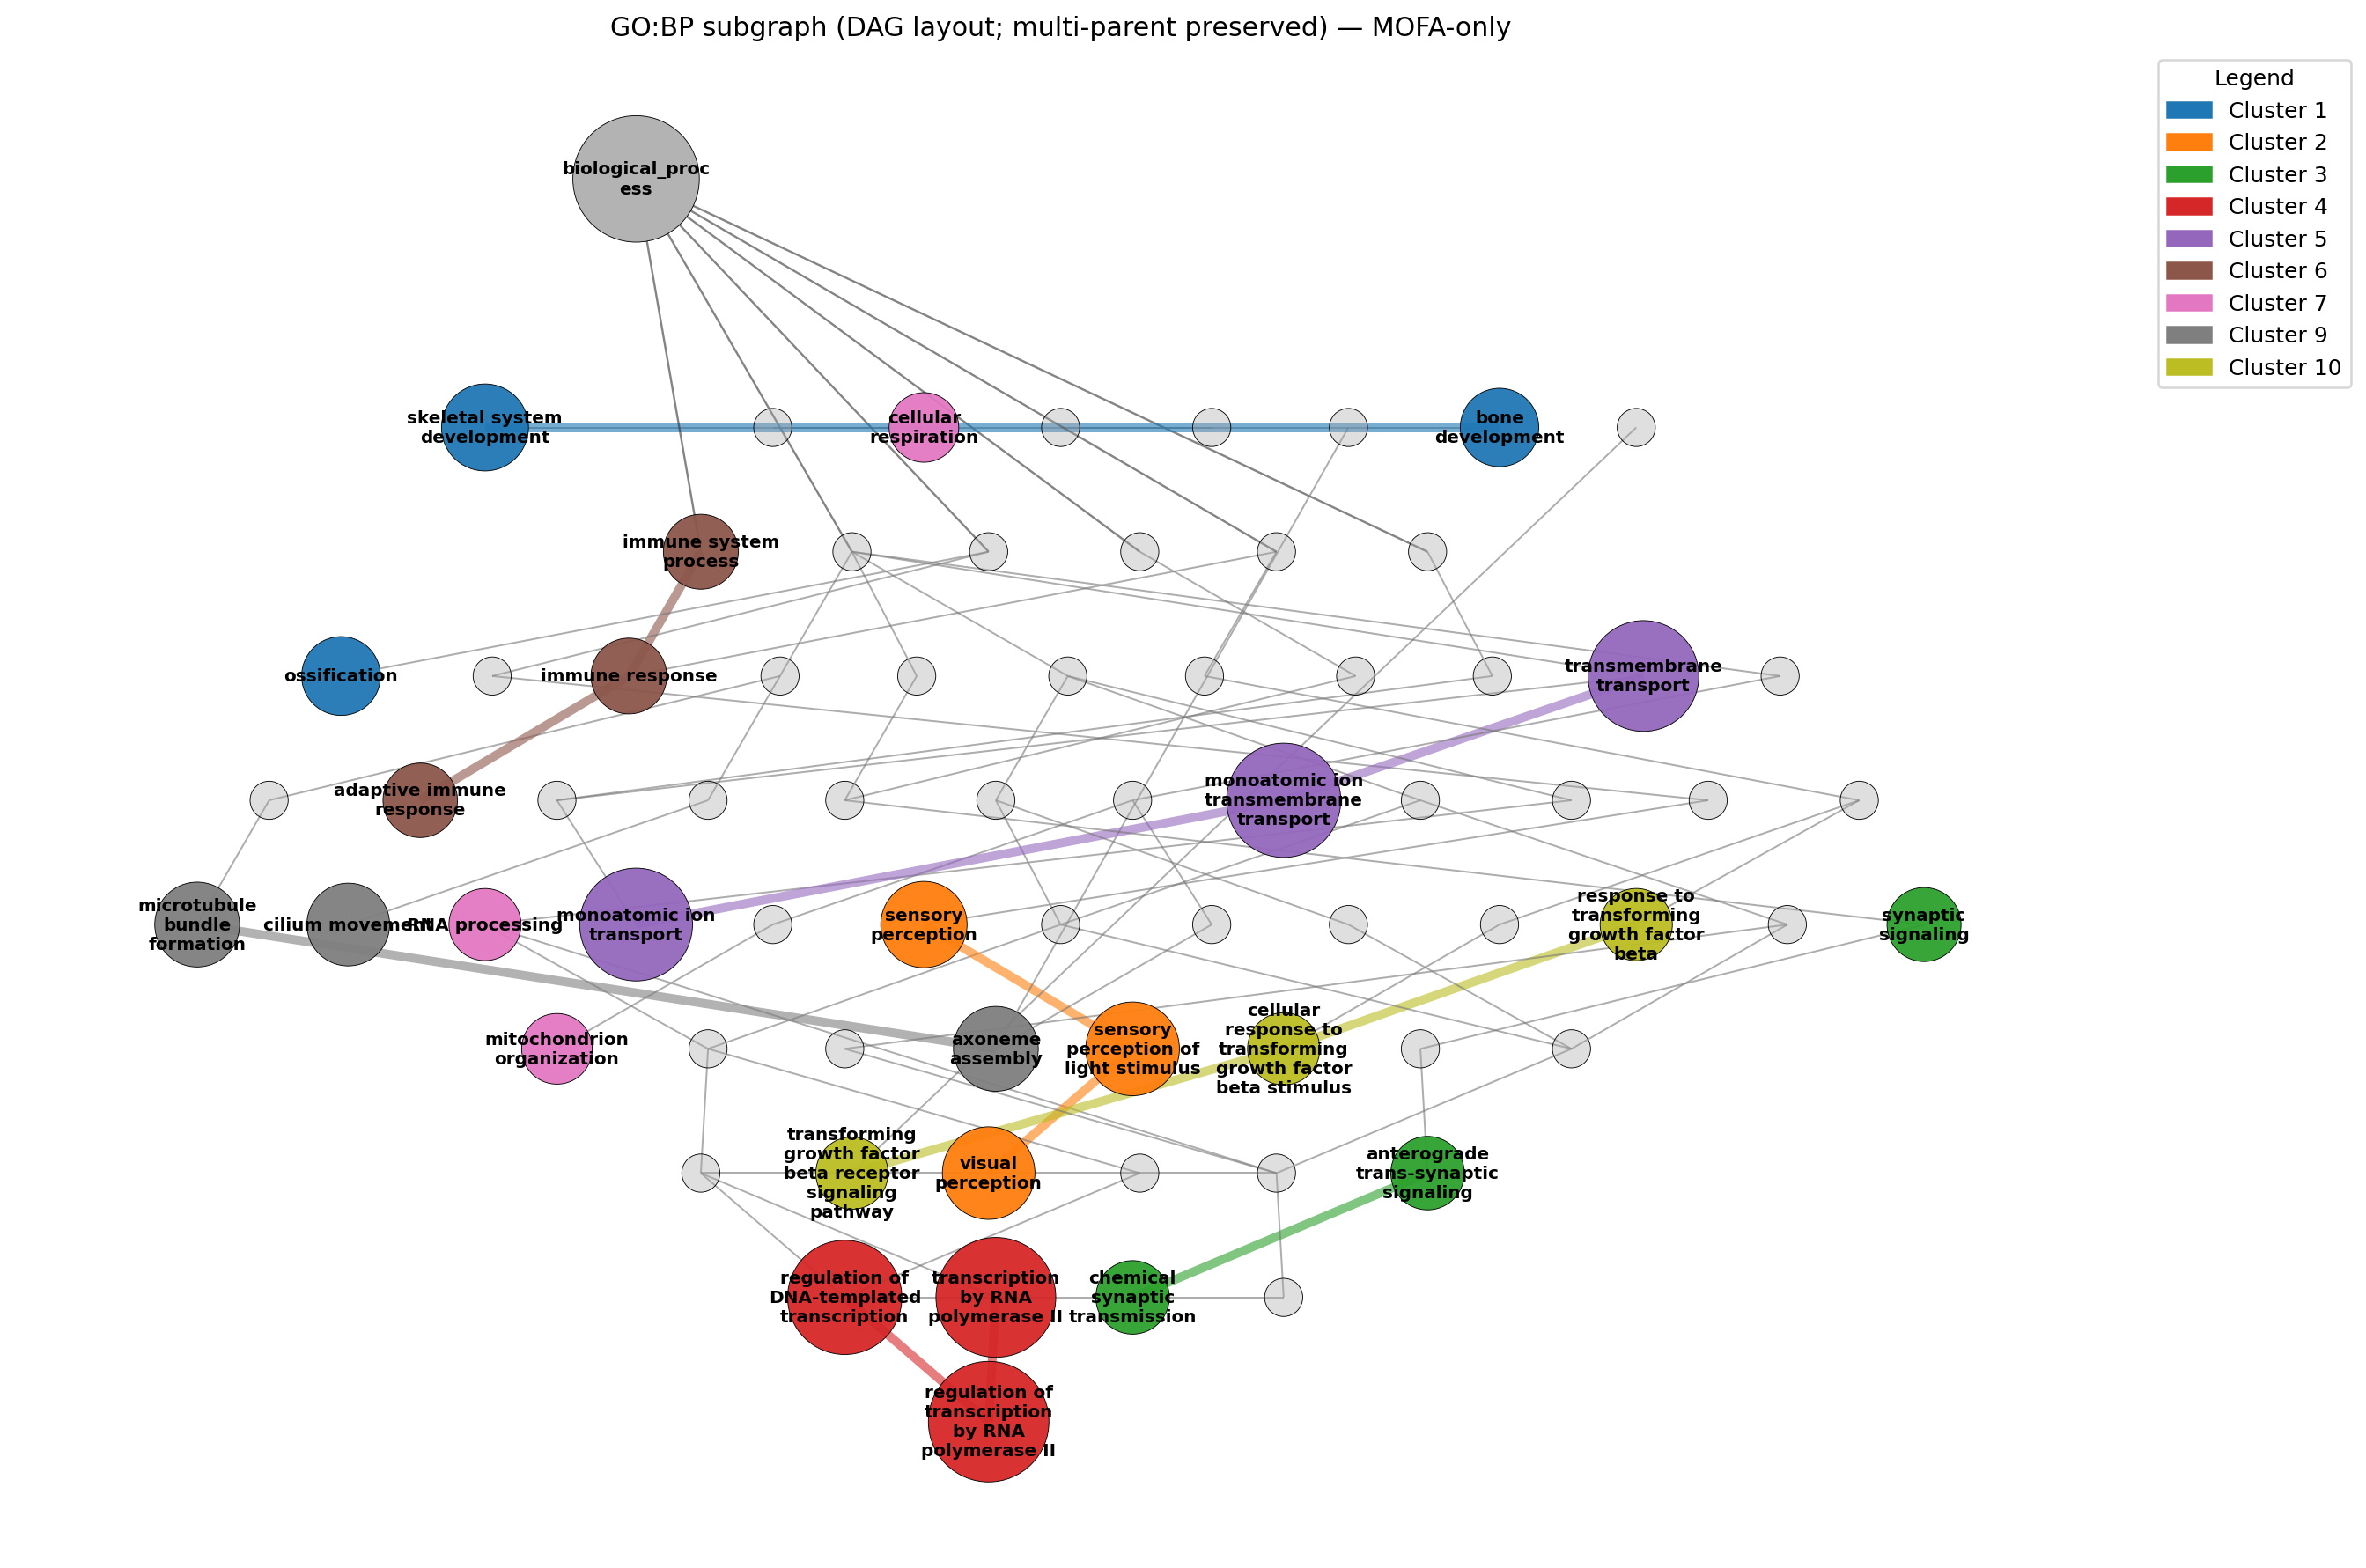

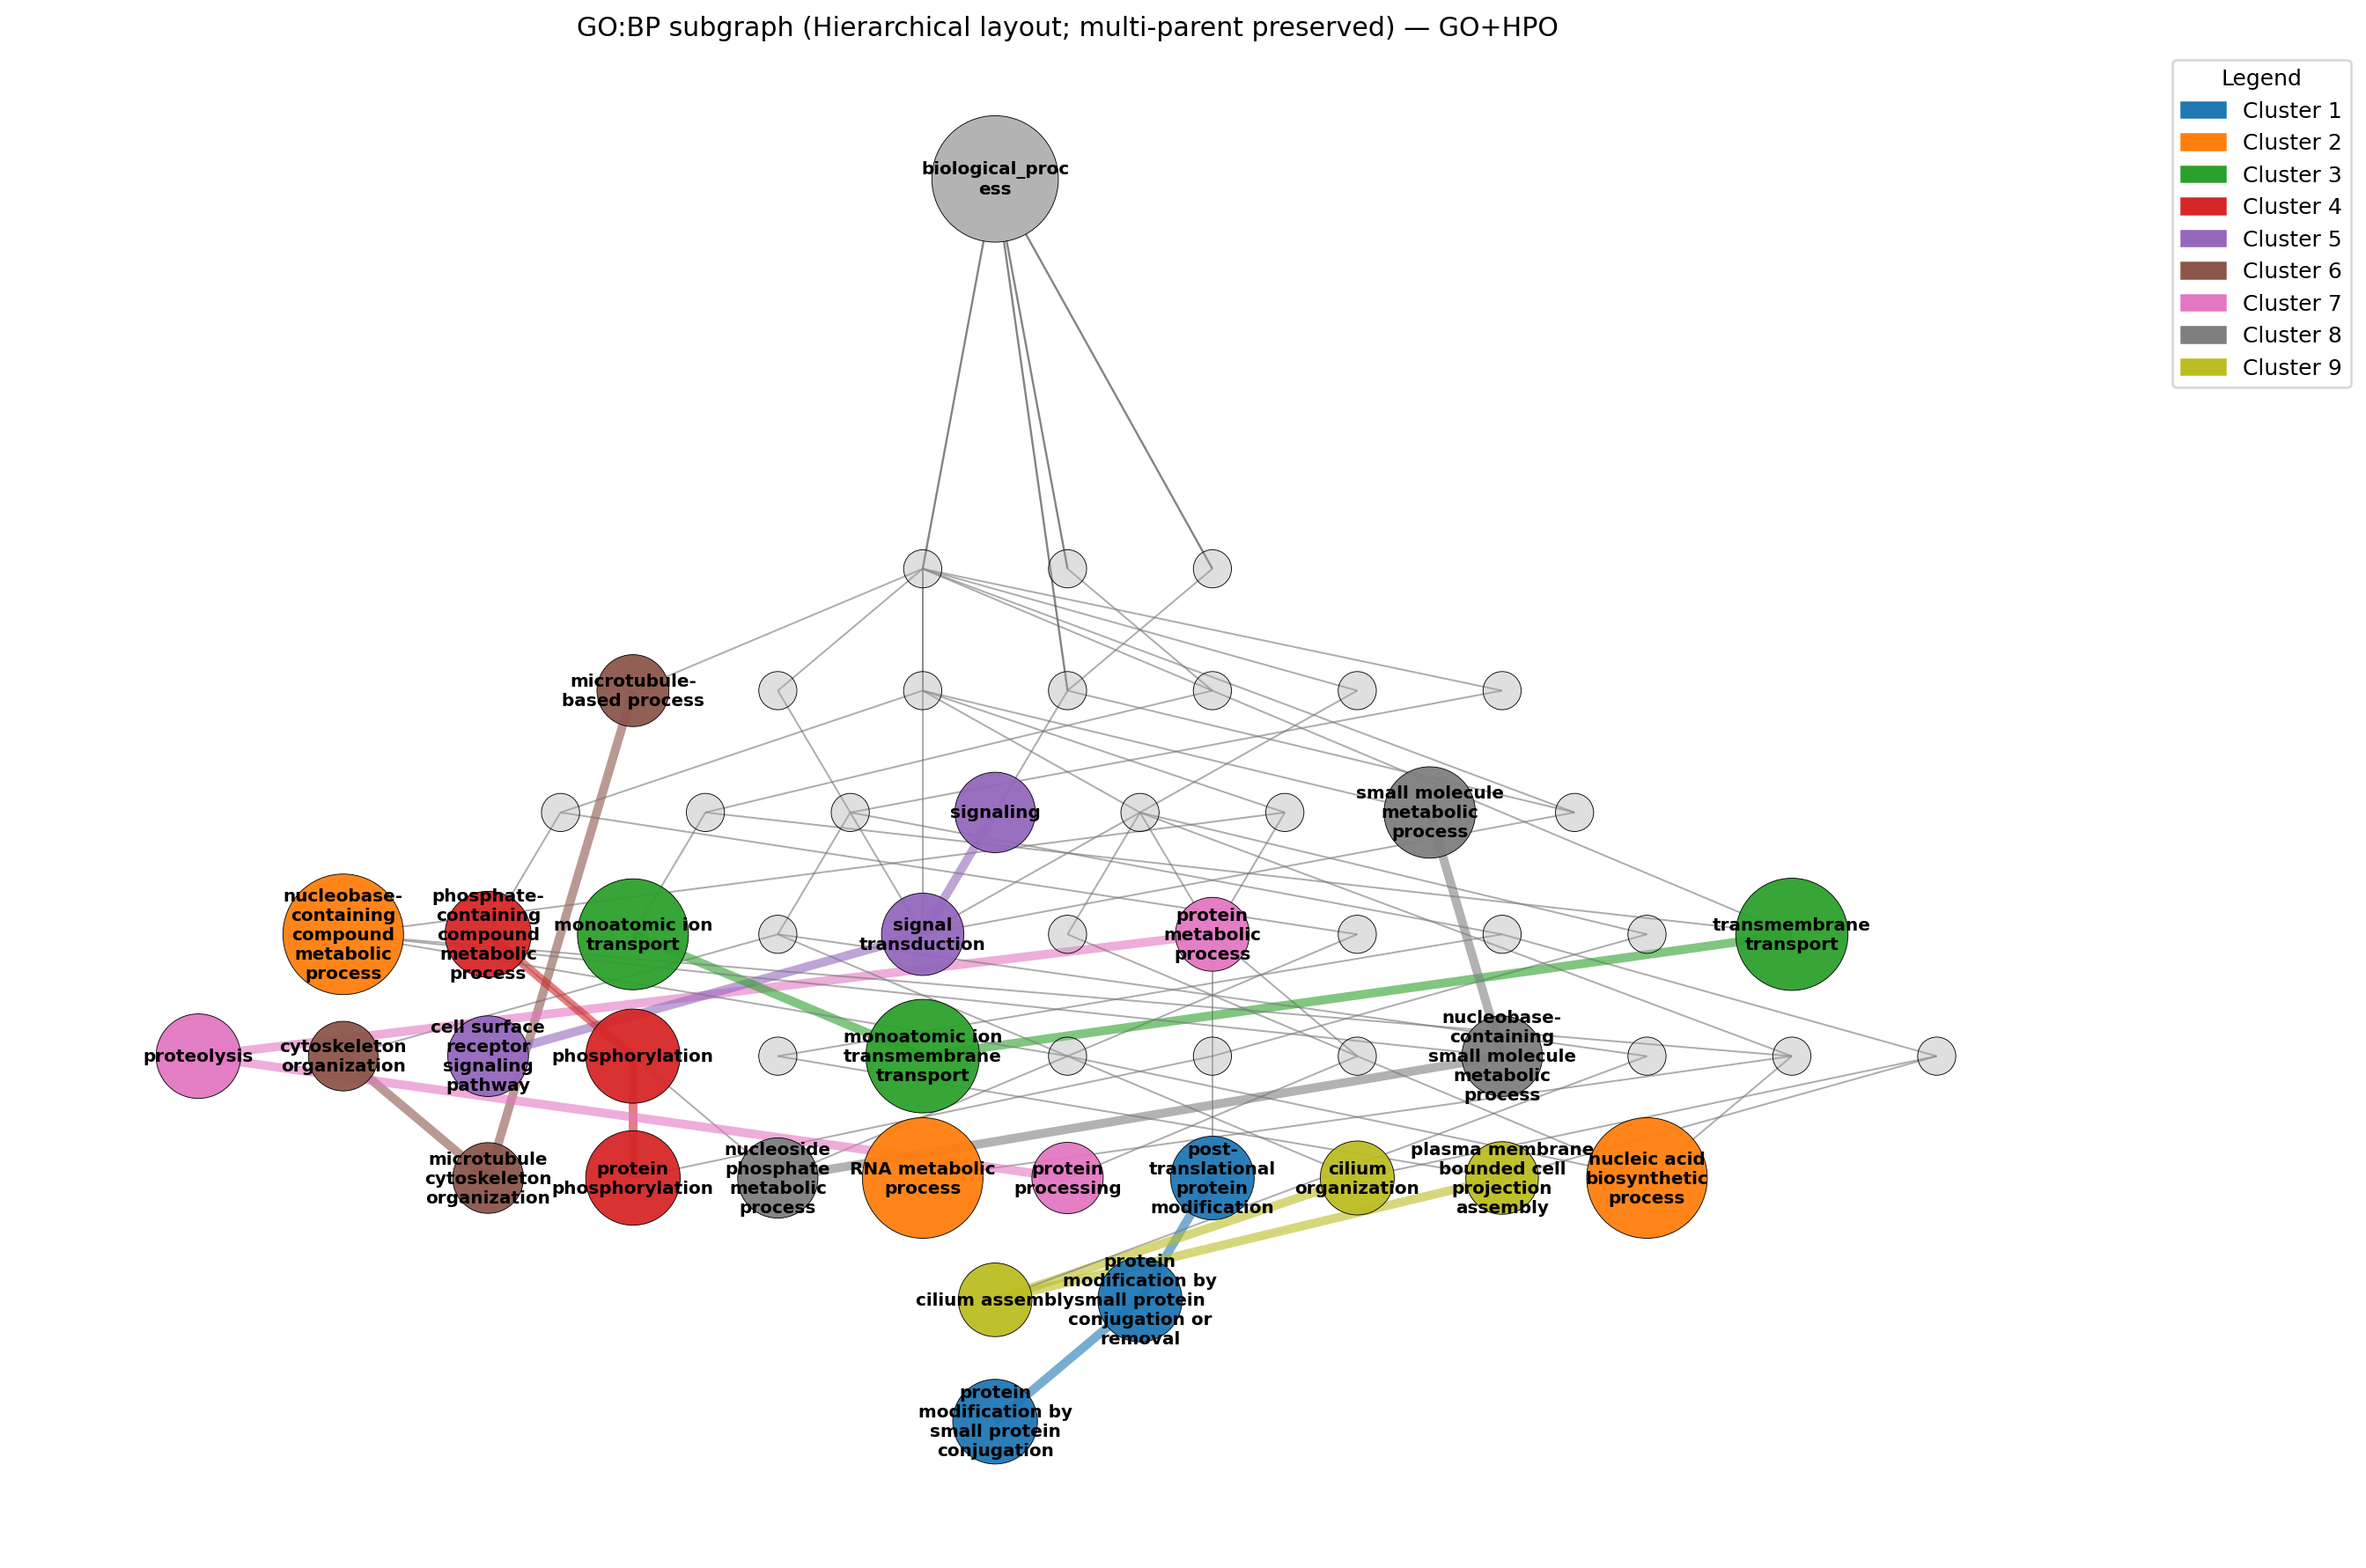

In [80]:
# Plot a GO:BP subgraph colored by consensus cluster (readable, sized by metric) for a given selection
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx

# ------------------ Layout Helpers ------------------

def _simple_layered_layout(G, rankdir='TB'):
    from collections import deque, defaultdict
    roots = [n for n in G.nodes() if G.in_degree(n) == 0]
    levels = {}
    dq = deque()
    for r in roots:
        levels[r] = 0
        dq.append(r)
    while dq:
        u = dq.popleft()
        for v in G.successors(u):
            lvl = levels[u] + 1
            if v not in levels or lvl > levels[v]:
                levels[v] = lvl
                dq.append(v)
    by_level = defaultdict(list)
    for n, l in levels.items():
        by_level[l].append(n)
    for n in G.nodes():
        if n not in levels:
            by_level[0].append(n)
            levels[n] = 0
    pos = {}
    for l in sorted(by_level.keys()):
        nodes = sorted(by_level[l])
        width = max(len(nodes) - 1, 1)
        x_offset = -width / 2.0
        for i, n in enumerate(nodes):
            x = x_offset + i
            y = -l if rankdir == 'TB' else l
            pos[n] = (x, y)
    return pos


def _hierarchical_layout(S, rankdir='TB', nodesep=0.8, ranksep=1.0):
    H = nx.DiGraph(S).reverse()  # parent->child
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        return graphviz_layout(H, prog='dot', args=f'-Grankdir={rankdir} -Gnodesep={nodesep} -Granksep={ranksep}')
    except Exception:
        try:
            from networkx.drawing.nx_pydot import graphviz_layout as pydot_graphviz_layout
            return pydot_graphviz_layout(H, prog='dot')
        except Exception:
            return _simple_layered_layout(H, rankdir=rankdir)


def _tree_layout(S, explicit_root=None, rankdir='TB'):
    H = nx.DiGraph(S).reverse()  # parent->child
    from collections import deque, defaultdict
    if explicit_root and explicit_root in H:
        roots = [explicit_root]
    else:
        roots = [n for n in H.nodes() if H.in_degree(n) == 0]
        if not roots and explicit_root in S:
            roots = [explicit_root]
    depth = {}
    dq = deque()
    for r in roots:
        depth[r] = 0
        dq.append(r)
    while dq:
        u = dq.popleft()
        for v in H.successors(u):
            d = depth[u] + 1
            if v not in depth:
                depth[v] = d
                dq.append(v)
            else:
                depth[v] = min(depth[v], d)
    levels = defaultdict(list)
    for n, d in depth.items():
        levels[d].append(n)
    for n in H.nodes():
        if n not in depth:
            depth[n] = 0
            levels[0].append(n)
    pos = {}
    y_sign = -1 if rankdir == 'TB' else 1
    for d in sorted(levels.keys()):
        nodes = sorted(levels[d])
        width = max(len(nodes) - 1, 1)
        x_offset = -width / 2.0
        for i, n in enumerate(nodes):
            x = x_offset + i
            y = y_sign * d
            pos[n] = (x, y)
    return pos


def _dag_layer_layout(S, root_ids=None, rankdir='TB', method='min'):
    """Layered layout for DAG preserving multiple parents.
    depth assignment supports multiple roots; depth of node determined by:
      method='min'  -> shortest distance from any root
      method='max'  -> longest distance from any root (emphasizes specificity)
    """
    H = nx.DiGraph(S).reverse()  # parent->child
    if root_ids:
        root_ids = [r for r in root_ids if r in H]
    if not root_ids:
        root_ids = [n for n in H.nodes() if H.in_degree(n) == 0]
    if not root_ids:
        root_ids = list(H.nodes())[:1]
    from collections import deque, defaultdict
    distances = {r: {r: 0} for r in root_ids}
    for r in root_ids:
        dq = deque([r])
        while dq:
            u = dq.popleft()
            for v in H.successors(u):
                d = distances[r][u] + 1
                if v not in distances[r] or d < distances[r][v]:
                    distances[r][v] = d
                    dq.append(v)
    node_depths = {}
    for n in H.nodes():
        d_vals = [distances[r][n] for r in root_ids if n in distances[r]]
        node_depths[n] = (min(d_vals) if method == 'min' else max(d_vals)) if d_vals else 0
    levels = defaultdict(list)
    for n, d in node_depths.items():
        levels[d].append(n)
    pos = {}
    y_sign = -1 if rankdir == 'TB' else 1
    for d in sorted(levels.keys()):
        nodes = sorted(levels[d])
        width = max(len(nodes) - 1, 1)
        x_offset = -width / 2.0
        for i, n in enumerate(nodes):
            jitter = (i % 2) * 0.05
            x = x_offset + i + jitter
            y = y_sign * d
            pos[n] = (x, y)
    return pos, node_depths

def wrap_label(text, width=18):
    import textwrap
    return '\n'.join(textwrap.wrap(text, width=width))

# ------------------ Plot Function ------------------

def plot_go_bp_graph(go_to_cluster, go_to_score, go_to_name, go_to_freq, title_suffix,
                     size_metric='significance', min_size=1000.0, max_size=3000.0,
                     label_mode='all', label_limit=60, anc_depth=4, seed=42,
                     layout='spring', rankdir='TB', include_full_ancestry=True,
                     root_id='GO:0008150', dag_depth_method='min', prune_mode='none',
                     edge_width_same=4, edge_width_diff=0.8, edge_color_diff="#777777",
                     filter_shared_ancestors=False, shared_threshold=2, keep_root=True,
                     inject_root_path=True,
                     spacing_scale=1.0, spring_k=1.2, hierarchical_nodesep=0.8, hierarchical_ranksep=1.0,
                     root_extra_gap=1.5, enforce_root_top=True, x_spacing_scale=1.0, y_spacing_scale=1.0):
    """Plot GO:BP consensus terms plus ancestors with selectable layout.

    Root options
    ------------
    keep_root : bool
        Retain root if present.
    inject_root_path : bool
        Inject root with edges to existing children if missing.
    enforce_root_top : bool
        Force root to remain alone at highest level (other nodes pushed down).
    root_extra_gap : float
        Additional vertical separation between root and all other nodes.

    Noise reduction
    ---------------
    filter_shared_ancestors : bool
        Keep ancestors summarizing >= shared_threshold selected terms.

    Spacing controls
    ----------------
    spacing_scale : float
        Uniform coordinate scaling.
    x_spacing_scale, y_spacing_scale : float
        Axis-specific scaling applied after uniform scaling.
    spring_k : float
        Rest distance for spring layout (larger => more spread).
    hierarchical_nodesep / hierarchical_ranksep : float
        Graphviz node / layer spacing for hierarchical layout.
    """
    selected_ids = list(go_to_cluster.keys())
    if len(selected_ids) == 0:
        print(f"No GO:BP terms to plot for {title_suffix}.")
        return

    # Collect ancestors
    nodes_keep = set(selected_ids)
    if include_full_ancestry:
        frontier = set(selected_ids)
        visited = set()
        while frontier:
            next_frontier = set()
            for node in frontier:
                if node in visited:
                    continue
                visited.add(node)
                if node in G_bp:
                    parents = [v for _, v in G_bp.out_edges(node)]
                    for p in parents:
                        nodes_keep.add(p)
                        if p != node:
                            next_frontier.add(p)
            frontier = next_frontier
    else:
        frontier = set(selected_ids)
        for _ in range(anc_depth):
            next_frontier = set()
            for node in frontier:
                if node in G_bp:
                    parents = [v for _, v in G_bp.out_edges(node)]
                    for p in parents:
                        nodes_keep.add(p)
                        next_frontier.add(p)
            frontier = next_frontier

    S = G_bp.subgraph(nodes_keep).copy()

    # Inject root if requested and absent
    if keep_root and inject_root_path and root_id in G_bp and root_id not in S:
        S.add_node(root_id, **G_bp.nodes[root_id])
        for child in G_bp.predecessors(root_id):
            if child in S:
                S.add_edge(child, root_id)

    # Optional: filter shared ancestors
    if filter_shared_ancestors and len(selected_ids) > 1 and S.number_of_nodes() > 0:
        H = nx.DiGraph(S).reverse()
        try:
            topo = list(nx.topological_sort(H))
        except Exception:
            topo = list(H.nodes())
        selected_set = set(selected_ids)
        desc_sets = {n: ({n} if n in selected_set else set()) for n in H.nodes()}
        for n in reversed(topo):
            for c in H.successors(n):
                if desc_sets[c]:
                    desc_sets[n] = desc_sets[n].union(desc_sets[c])
        keep_nodes = set(selected_ids)
        if keep_root and root_id in S:
            keep_nodes.add(root_id)
        for n in S.nodes():
            if n in keep_nodes:
                continue
            if len(desc_sets.get(n, set())) >= int(shared_threshold):
                keep_nodes.add(n)
        for s in selected_ids:
            parents = [v for _, v in G_bp.out_edges(s) if v in S]
            keep_nodes.update(parents)
        S = S.subgraph(keep_nodes).copy()

    # Pruning strategies
    if prune_mode != 'none':
        for _ in range(5):
            removed = []
            for n in list(S.nodes()):
                if n in selected_ids or n == root_id:
                    continue
                children = [c for c, p in G_bp.in_edges(n) if p == n and c in selected_ids]
                if prune_mode == 'light':
                    if not any((nbr in selected_ids) for nbr in S.neighbors(n)):
                        removed.append(n)
                elif prune_mode == 'aggressive':
                    if S.degree(n) <= 1 and not children:
                        removed.append(n)
            if not removed:
                break
            S.remove_nodes_from(removed)

    clusters_present = sorted({go_to_cluster[g] for g in selected_ids})
    cmap = plt.cm.get_cmap('tab10', max(10, len(clusters_present)))
    cluster_to_color = {cid: cmap(i % 10) for i, cid in enumerate(clusters_present)}

    def metric_value(n):
        if size_metric == 'frequency':
            return float(go_to_freq.get(n, 1))
        elif size_metric == 'hybrid':
            sig = float(go_to_score.get(n, 1.0))
            freq = float(go_to_freq.get(n, 1))
            return sig * np.log2(1.0 + freq)
        else:
            return float(go_to_score.get(n, 1.0))

    metric_vals = np.array([metric_value(n) for n in selected_ids], dtype=float)
    if np.allclose(metric_vals.min(), metric_vals.max()):
        norm_sizes = np.full_like(metric_vals, (min_size + max_size) / 2.0)
    else:
        vmin, vmax = metric_vals.min(), metric_vals.max()
        norm_sizes = min_size + (metric_vals - vmin) / (vmax - vmin) * (max_size - min_size)
    size_map = {n: s for n, s in zip(selected_ids, norm_sizes)}

    node_colors = []
    node_sizes = []
    labels = {}
    for n in S.nodes():
        if n == root_id:
            c = (0.7, 0.7, 0.7, 1.0)
            s = max_size * 1.1
        elif n in go_to_cluster:
            base_rgba = cluster_to_color[go_to_cluster[n]]
            c = (base_rgba[0], base_rgba[1], base_rgba[2], 0.95)
            s = float(size_map.get(n, (min_size + max_size) / 2.0))
        else:
            c = (0.65, 0.65, 0.65, 0.35)
            s = min_size * 0.30
        node_colors.append(c)
        labels[n] = wrap_label(go_to_name.get(n, G_bp.nodes[n].get('name', n)), width=15)
        node_sizes.append(s)

    plt.figure(figsize=(15, 10), dpi=180)
    if layout == 'hierarchical':
        pos = _hierarchical_layout(S, rankdir=rankdir, nodesep=hierarchical_nodesep, ranksep=hierarchical_ranksep)
    elif layout == 'tree':
        pos = _tree_layout(S, explicit_root=root_id, rankdir=rankdir)
    elif layout == 'dag':
        pos, depths = _dag_layer_layout(S, root_ids=[root_id] if root_id in S else None, rankdir=rankdir, method=dag_depth_method)
    else:
        pos = nx.spring_layout(S, seed=seed, k=spring_k, iterations=300)

    # Enforce root isolation at highest level
    if enforce_root_top and root_id in pos and root_extra_gap > 0:
        root_y = pos[root_id][1]
        for n in pos:
            if n == root_id:
                continue
            if rankdir == 'TB':
                if pos[n][1] >= root_y - 1e-9:  # same or above root
                    pos[n] = (pos[n][0], pos[n][1] - root_extra_gap)
                else:
                    pos[n] = (pos[n][0], pos[n][1] - root_extra_gap)
            else:  # BT or other
                if pos[n][1] <= root_y + 1e-9:
                    pos[n] = (pos[n][0], pos[n][1] + root_extra_gap)
                else:
                    pos[n] = (pos[n][0], pos[n][1] + root_extra_gap)

    # Apply uniform & anisotropic spacing scales
    if spacing_scale != 1.0 or x_spacing_scale != 1.0 or y_spacing_scale != 1.0:
        for n, (x, y) in pos.items():
            pos[n] = (x * spacing_scale * x_spacing_scale, y * spacing_scale * y_spacing_scale)

    edges_list = list(S.edges())
    edge_widths = []
    edge_colors = []
    for u, v in edges_list:
        cu = go_to_cluster.get(u)
        cv = go_to_cluster.get(v)
        if u == root_id or v == root_id:
            edge_widths.append(edge_width_diff * 1.2)
            edge_colors.append('#333333')
        elif cu is not None and cv is not None and cu == cv:
            edge_widths.append(edge_width_same)
            edge_colors.append(cluster_to_color[cu])
        else:
            edge_widths.append(edge_width_diff)
            edge_colors.append(edge_color_diff)

    nx.draw_networkx_edges(
        S, pos, edgelist=edges_list, width=edge_widths, edge_color=edge_colors, alpha=0.6, arrows=False
    )
    nx.draw_networkx_nodes(S, pos, node_color=node_colors, node_size=node_sizes, edgecolors='k', linewidths=0.35)

    if label_mode != 'none':
        if label_mode == 'topN':
            order_nodes = sorted(selected_ids, key=lambda n: metric_value(n), reverse=True)
            label_nodes = order_nodes[:min(label_limit, len(order_nodes))]
        else:
            label_nodes = selected_ids[:min(label_limit, len(selected_ids))]
        if root_id in S:
            label_nodes = list(dict.fromkeys([root_id] + label_nodes))
        sel_labels = {n: labels[n] for n in label_nodes if n in S}
        nx.draw_networkx_labels(S, pos, labels=sel_labels, font_size=8, font_weight='bold')

    handles = [mpatches.Patch(color=cluster_to_color[cid], label=f"Cluster {cid}") for cid in clusters_present]
    plt.legend(handles=handles, title="Legend", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.axis('off')
    layout_label = {'tree':'Tree','hierarchical':'Hierarchical','spring':'Spring','dag':'DAG'}[layout]
    plt.title(f'GO:BP subgraph ({layout_label} layout; multi-parent preserved) — {title_suffix}')
    plt.tight_layout()
    plt.show()

# Example usage with isolated root & enhanced spacing
plot_go_bp_graph(go_to_cluster_mofa, go_to_score_mofa, go_to_name_mofa, go_to_freq_mofa,
                 title_suffix="MOFA-only", layout='dag', include_full_ancestry=False, anc_depth=3,
                 dag_depth_method='max', filter_shared_ancestors=True, shared_threshold=3,
                 keep_root=True, inject_root_path=True, root_extra_gap=2.0, enforce_root_top=True,
                 spacing_scale=1.3, x_spacing_scale=1.4, y_spacing_scale=1.6)
plot_go_bp_graph(go_to_cluster_gohpo, go_to_score_gohpo, go_to_name_gohpo, go_to_freq_gohpo,
                 title_suffix="GO+HPO", layout='hierarchical', include_full_ancestry=False, anc_depth=3,
                 dag_depth_method='min', filter_shared_ancestors=True, shared_threshold=3,
                 keep_root=True, inject_root_path=True, root_extra_gap=2.2, enforce_root_top=True,
                 hierarchical_nodesep=1.5, hierarchical_ranksep=1.4, spacing_scale=1.2, x_spacing_scale=1.3, y_spacing_scale=1.5)
